<a href="https://colab.research.google.com/github/Nirzaree/STAC-spec/blob/stac-spec-common/generate_stac_pan_india_raster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [6]:

%pip install --quiet geopandas fiona

%pip install rasterio

%pip install pystac



In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
import os

import json
import xml.etree.ElementTree as ET
import datetime
import requests
from io import BytesIO

from rasterio.warp import transform_bounds

from matplotlib.colors import ListedColormap, Normalize
from shapely.geometry import mapping, box, Polygon
from IPython.display import Image, display

import numpy as np
import pystac
from pystac.extensions.table import TableExtension
from pystac import Asset, MediaType
from pystac.extensions.classification import ClassificationExtension, Classification
from pystac.extensions.raster import RasterExtension,RasterBand
from pystac.extensions.projection import ProjectionExtension


In [8]:


raster_path = "/content/drive/MyDrive/stactest/WRIRestoration.tif"



In [9]:
def read_raster_data(raster_path, downsample_size=(512, 512)):
    with rasterio.open(raster_path) as r:

        data = r.read(
            1,
            out_shape=downsample_size,
            resampling=rasterio.enums.Resampling.nearest
        )
        crs = r.crs
        bounds = r.bounds
        bbox = [bounds.left, bounds.bottom, bounds.right, bounds.top]
        id = os.path.basename(raster_path)
        shape = data.shape
        data_type = str(data.dtype)


        footprint = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

        return (data,
                bbox,
                mapping(footprint),
                crs,
                id,
                None,
                shape,
                data_type
                )

In [30]:
raster_data,bbox,footprint,crs,id,gsd,shape,data_type = read_raster_data(raster_path)

In [32]:
bbox

[66.33178024244229, 6.460324197273955, 100.20778859575992, 38.36471016500606]

In [33]:
crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [38]:
gsd

In [34]:
data_type

'uint8'

In [41]:

item_id = 'Landscape-Restoration-WRI'

raster_item = pystac.Item(id=item_id,
                      geometry=footprint,
                      bbox=bbox,
                      datetime=datetime.datetime.now(datetime.timezone.utc),
                      properties={
                        #   title
                        # description
                          # "gsd": gsd, #adding this in raster extension
                      })

In [40]:
raster_item

<Item id=Landscape-Restoration-WRI>

In [13]:
proj_ext = ProjectionExtension.ext(raster_item, add_if_missing=True)
proj_ext.epsg = crs
#proj_ext.shape = [shape[0], shape[1]]

In [14]:
raster_item.add_asset("data", Asset(
    href=raster_path,
    media_type=MediaType.GEOTIFF,
    roles=["data"],
    title="Raster Layer"
))

In [15]:
github_style_file='https://raw.githubusercontent.com/core-stack-org/QGIS-Styles/main/Restoration/Restoration_style.qml'

In [16]:
def parse_raster_style_file(github_style_file):

    try:
        response = requests.get(github_style_file, verify=False)
        response.raise_for_status()


        tree = ET.parse(BytesIO(response.content))
        root = tree.getroot()
        classes = []

        for entry in root.findall(".//paletteEntry"):
            class_info = {}
            for attr_key, attr_value in entry.attrib.items():
                if attr_key == "value":
                    try:
                        class_info[attr_key] = int(attr_value)
                    except ValueError:
                        class_info[attr_key] = attr_value
                else:
                    class_info[attr_key] = attr_value
            classes.append(class_info)

        if not classes:
            for entry in root.findall(".//item"):
                class_info = {}
                for attr_key, attr_value in entry.attrib.items():
                    if attr_key == "value":
                        try:
                            class_info[attr_key] = int(attr_value)
                        except ValueError:
                            class_info[attr_key] = attr_value
                    else:
                        class_info[attr_key] = attr_value
                classes.append(class_info)
        return classes

    except requests.exceptions.RequestException as e:
        print(f"Error fetching QML file from URL: {e}")
        return None
    except ET.ParseError as e:
        print(f"Error parsing XML from QML file: {e}")
        return None

In [17]:
style_info = parse_raster_style_file(github_style_file)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [18]:
style_info

[{'color': '#d2d2d2', 'value': 0, 'label': 'Excluded', 'alpha': '0'},
 {'color': '#d79b0f',
  'value': 1,
  'label': 'Mosain Restoration',
  'alpha': '255'},
 {'color': '#0f077c',
  'value': 2,
  'label': 'Wide scale Restoration',
  'alpha': '255'},
 {'color': '#4fbc14', 'value': 3, 'label': 'Protection', 'alpha': '255'}]

In [19]:
classification_ext = ClassificationExtension.ext(raster_item.assets["data"], add_if_missing=True)
stac_classes = []
for cls in style_info:
    stac_class_obj = Classification.create(
        value=int(cls["value"]),
        name=cls.get("label") or f"Class {cls['value']}",
        description=cls.get("label"),
        color_hint=cls['color'].replace('#','')
    )
    stac_classes.append(stac_class_obj)
classification_ext.classes = stac_classes

In [20]:
raster_item.add_asset("style", Asset(
    href=github_style_file,
    media_type=MediaType.XML,
    roles=["metadata"],
    title="Raster Style (QML)"
))

In [21]:
raster_item

<Item id=Landscape-Restoration-WRI>

In [22]:
output_dir = '../data/'


raster_thumbnail_path = os.path.join(
    output_dir,
    raster_path.split('.')[0] + '_thumbnail.png'
)

In [23]:
def generate_raster_thumbnail(raster_data,
                              style_info,
                              output_path
                              ):

    unique_raster_values = np.unique(raster_data.compressed() if isinstance(raster_data, np.ma.MaskedArray) else raster_data)
    # Filter QML info to only include values present in the raster data
    filtered_style_info = [cls for cls in style_info if cls.get('value') in unique_raster_values]

    values = [cls['value'] for cls in filtered_style_info if 'value' in cls]
    colors = [cls['color'] for cls in filtered_style_info if 'color' in cls]

    # print(f"Parsed QML values: {values}")
    # print(f"Parsed QML colors: {colors}")

    try:
        if not values or not colors or len(values) != len(colors):
            raise ValueError("Invalid or insufficient palette information in QML file.")

        sorted_indices = np.argsort(values)
        sorted_values = np.array(values)[sorted_indices]
        sorted_colors = np.array(colors)[sorted_indices]

        cmap = ListedColormap(sorted_colors)
        bounds = np.array(sorted_values) - 0.5
        bounds = np.append(bounds, sorted_values[-1] + 0.5)
        norm = Normalize(vmin=bounds.min(), vmax=bounds.max())

    except ValueError as e:
        print(f"Skipping palette generation due to error: {e}. Using a default colormap.")
        cmap = 'gray'
        norm = None
    plt.figure(figsize=(3, 3), dpi=100)

    plt.imshow(raster_data, cmap=cmap, norm=norm, interpolation='none')
    plt.axis('off')

    #os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [26]:
generate_raster_thumbnail(
    raster_data=raster_data,
    style_info=style_info,
    output_path= raster_thumbnail_path
)

In [27]:
os.makedirs(os.path.dirname(raster_thumbnail_path),exist_ok=True)

In [28]:
root_catalog = pystac.Catalog(
    id="PANindia",
    title="STAC Catalog for PAN India",
    description="STAC items for PAN india."
)
root_catalog.add_item(raster_item)

print("STAC Item and Catalog created successfully!")
print("STAC Item ID:", raster_item.id)
print("Item's Parent Catalog:", raster_item.get_parent().id)

STAC Item and Catalog created successfully!
STAC Item ID: Landscape-Restoration-WRI
Item's Parent Catalog: PANindia


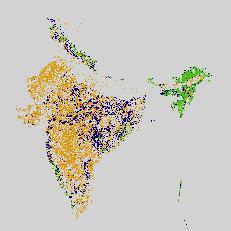

In [29]:
display(Image(filename=raster_thumbnail_path))